## 1. Introduction

This notebook focuses on **Step 4 - Learning Rate Optimization**, where we aim to find the optimal learning rate for our top-performing models. We will apply a learning rate scheduler to gradually increase the learning rate during training, starting from a very low value and increasing exponentially up to approximately 2.54.

### Objective:
- **Exponential Learning Rate Increase**: Start training with a very low learning rate (0.00001) and gradually increase it throughout the epochs until it reaches approximately 2.54.
- **Evaluate Performance**: Analyze the loss, accuracy, and F1-Score Weighted curves across epochs to identify the optimal learning rate that minimizes the loss while optimizing for class imbalance using F1-Score Weighted.
- **Ensure Stability**: This method helps identify the learning rate that achieves the best convergence without causing overfitting or underfitting.

For more details on the methodology, refer to [this article](https://towardsdatascience.com/how-to-optimize-learning-rate-with-tensorflow-its-easier-than-you-think-164f980a7c7b/).

### Adjustments for Our Case:
1. **Metric for Optimization**: While the original article uses accuracy, we will optimize based on the **F1-Score Weighted**, as it is more suitable for imbalanced datasets. During the learning rate range test, we will focus on the **F1-Score Weighted** as our evaluation metric.
   
2. **Learning Rate Range**: We will stick with the exponential learning rate increase, but instead of adjusting the increase rate across many epochs, we will use a fixed number of epochs (100). By reducing the dataset size for quicker iterations, we aim to optimize the learning rate without compromising on the quality of results.

3. **Training Setup**:
   - **Callbacks**: We will not use early stopping or checkpoints since we are solely focused on identifying the best learning rate. Instead, we will monitor the **F1-Score Weighted** throughout the epochs to guide our learning rate choice.
   - **LearningRateScheduler**: We will use TensorFlow's `LearningRateScheduler` to control the exponential increase of the learning rate during training.

4. **Dataset Size**: We will reduce the size of the training dataset to speed up the learning rate optimization process, ensuring the data is still representative. We will retain the **class weights** to address class imbalance, ensuring the model is sensitive to underrepresented classes.

### Key Focus for This Notebook:
- Optimize the learning rate using the **Learning Rate Range Test** for models including **MobileNetV2**, **DenseNet121**, **InceptionResNetV2**, **Xception**, and **InceptionV3**.
- Focus on the **F1-Score Weighted** metric for performance evaluation instead of accuracy.
- Use a smaller dataset size (while retaining class weights) and focus on optimizing the learning rate within 100 epochs.
- Monitor and adjust the learning rate using the **LearningRateScheduler** callback and track the **F1-Score Weighted** to guide our optimization process.

By the end of this process, we will identify the optimal learning rate that results in the highest **F1-Score Weighted**, thus improving the performance of the models on imbalanced datasets.


##  2. Import Required Libraries & Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import os
import sys
from pathlib import Path
import importlib

# Data science and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow and Keras libraries for model building and image preprocessing
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Scikit-learn metrics for model evaluation
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

# Setup dynamic project paths
CURRENT_DIR = Path(os.getcwd()).resolve()
PROJECT_ROOT = CURRENT_DIR.parents[2]
sys.path.append(str(PROJECT_ROOT))

def get_relative_path(absolute_path):
    return str(Path(absolute_path).relative_to(PROJECT_ROOT))

print(f"Project Root Directory: {PROJECT_ROOT.name}")

# Load project config and modules from src
import config

Project Root Directory: Data_Scientist_Rakuten_Project-main


 ## 3.  Meta data import and Preprocessing

 ### 3.1 Import Image Metadata

In [2]:
import src.data_preprocessing.load_image_metadata
importlib.reload(src.data_preprocessing.load_image_metadata)
from src.data_preprocessing.load_image_metadata import load_image_metadata
from sklearn.utils.class_weight import compute_class_weight

# Call the function
X_train_split, X_val_split, prdtypecode_mapping = load_image_metadata()

# Display the reduced dataset sizes
print(f"\ntraining dataset size: {X_train_split.shape}")
print(f"dataset size: {X_val_split.shape}")


[✔] Loaded `X_train_split` | Type: <class 'pandas.core.frame.DataFrame'>


,designation,description,text,productid,imageid,prdtypecode,prdtypecode_encoded,Label,image_name
1887,porte bebe violet rouge trois mere multifoncti...,Porte bébé Violet et rouge Trois-en-un mère mu...,porte bebe violet rouge trois mere multifoncti...,3050424970,1187504001,1320,12,Early Childhood,image_1187504001_product_3050424970.jpg


[✔] Loaded `X_val_split` | Type: <class 'pandas.core.frame.DataFrame'>


,designation,description,text,productid,imageid,prdtypecode,prdtypecode_encoded,Label,image_name
81432,bas filles enfants enfants collant coton bebe ...,Filles Bas Enfants Enfants Collant Coton bébé ...,bas filles enfants collant coton bebe stocking...,3898715946,1261369347,1301,10,Accessories for Children,image_1261369347_product_3898715946.jpg


[✔] Loaded `prdtypecode_mapping` | Type: <class 'pandas.core.frame.DataFrame'>


,Original prdtypecode,Encoded target,Label
0,10,0,Adult Books



training dataset size: (67932, 9)
dataset size: (16984, 9)


 ### 3.2 Dataset Size Reduction for Learning Rate Optimization
    
In order to speed up the process of Learning Rate Optimization, we will reduce the training dataset size while ensuring that it still maintains the diversity and distribution of the original data. This allows for faster experimentation without losing the representativeness of the dataset. However, we will retain the class weights to ensure that the model remains sensitive to class imbalances during training.

We will reduce the dataset to **10-20%** of the original size for both training and validation datasets while keeping the original class distribution intact. This approach helps us find the optimal learning rate faster while still preserving the key characteristics of the full dataset.

The next step is to load the image metadata, split the dataset, and compute the class weights, which will be applied during training.


In [3]:
from sklearn.model_selection import train_test_split


# X_train_split, X_val_split, prdtypecode_mapping = load_image_metadata()

## Display original size of datasets
print(f"\nOriginal training dataset size: {X_train_split.shape}")
print(f"Original validation dataset size: {X_val_split.shape}")


# Stratified sampling to maintain the class distribution
X_train_split_reduced, _, y_train_split_reduced, _ = train_test_split(
    X_train_split, 
    X_train_split['prdtypecode_encoded'],  # Use the target variable (class labels)
    test_size=0.8,  # Keep 20% of the data for training
    stratify=X_train_split['prdtypecode_encoded'],  # Stratified split to maintain class distribution
    random_state=42
)

# For validation set, use the same approach
X_val_split_reduced, _, y_val_split_reduced, _ = train_test_split(
    X_val_split, 
    X_val_split['prdtypecode_encoded'],  # Use the target variable (class labels)
    test_size=0.8,  # Keep 20% of the data for validation
    stratify=X_val_split['prdtypecode_encoded'],  # Stratified split to maintain class distribution
    random_state=42
)

# Update X_train_split and X_val_split to use the reduced versions
X_train_split = X_train_split_reduced
X_val_split = X_val_split_reduced

# Display the reduced dataset sizes
print(f"\nReduced training dataset size: {X_train_split.shape}")
print(f"Reduced validation dataset size: {X_val_split.shape}")



Original training dataset size: (67932, 9)
Original validation dataset size: (16984, 9)

Reduced training dataset size: (13586, 9)
Reduced validation dataset size: (3396, 9)


 ### 3.3 Class Weights Calculation

In [4]:
class_labels = np.unique(X_train_split["prdtypecode_encoded"])
class_counts = {label: np.sum(X_train_split["prdtypecode_encoded"] == label) for label in class_labels}

print('\nclass_counts:')
print(class_counts)

# Compute class weights based on distribution
class_weights = compute_class_weight('balanced', classes=class_labels, y=X_train_split["prdtypecode_encoded"])
class_weight_dict = {class_labels[i]: class_weights[i] for i in range(len(class_labels))}
class_weight_dict = {int(key): value for key, value in class_weight_dict.items()}

for label, weight in list(class_weight_dict.items())[:5]:
    print(f"Class {label}: Adjusted weight: {weight}")


class_counts:
{0: 499, 1: 401, 2: 269, 3: 133, 4: 427, 5: 632, 6: 122, 7: 779, 8: 331, 9: 807, 10: 129, 11: 399, 12: 519, 13: 812, 14: 688, 15: 129, 16: 799, 17: 132, 18: 762, 19: 764, 20: 227, 21: 798, 22: 414, 23: 1633, 24: 399, 25: 442, 26: 140}
Class 0: Adjusted weight: 1.0083871446596897
Class 1: Adjusted weight: 1.2548258982174194
Class 2: Adjusted weight: 1.8705768965992013
Class 3: Adjusted weight: 3.7833472570314677
Class 4: Adjusted weight: 1.178419637436031


 ## 4. Global Training Parameters

### 4.1 Training Parameters

In [5]:
# Training parameters
NUM_CLASSES = 27

# #Quick testing
# EPOCHS = 20 
# BATCH_SIZE = 32
# LEARNING_RATE = 0.00001


EPOCHS = 100
BATCH_SIZE = 64
LEARNING_RATE = 0.00001

class_names = [str(key) for key in prdtypecode_mapping.keys()]

in_shape_224 = (224,224,3)
in_shape_299 = (299,299,3)

MODEL_DIR = Path(config.LR_OPTIMIZATION_DIR)
STEP_NAME = 'Step4'

 ### 4.2 Data Generators

In [6]:
import src.modeling_image.data_augmentation
importlib.reload(src.modeling_image.data_augmentation)
from src.modeling_image.data_augmentation import create_data_augmentation_generator


#  Data Generators for  MobileNetV2, DenseNet121 (224x224)
train_gen_224x224, valid_gen_224x224 = create_data_augmentation_generator(
    input_size=(224, 224),  # For models that use (224, 224)
    batch_size=BATCH_SIZE, 
    train_data=X_train_split, 
    validation_data=X_val_split, 
    augment=False # augment to False augmentation is not enabled, only rescale the images
)

#  Data Generators for  InceptionResNetV2, Xception, InceptionV3 (299x299)
train_gen_299x299, valid_gen_299x299 = create_data_augmentation_generator(
    input_size=(299, 299),  # For models that use (299, 299)
    batch_size=BATCH_SIZE, 
    train_data=X_train_split, 
    validation_data=X_val_split, 
    augment=False # augment to False augmentation is not enabled, only rescale the images
)



Received arguments:
input_size          : (224, 224)
batch_size          : 64
augment             : False
train_data_shape    : (13586, 9)
validation_data_shape: (3396, 9)

Found 13586 validated image filenames belonging to 27 classes.
Found 3396 validated image filenames belonging to 27 classes.

Received arguments:
input_size          : (299, 299)
batch_size          : 64
augment             : False
train_data_shape    : (13586, 9)
validation_data_shape: (3396, 9)

Found 13586 validated image filenames belonging to 27 classes.
Found 3396 validated image filenames belonging to 27 classes.


## 5. Learning Rate Optimization (LR Range Test)

###  5.1 Learning Rate Scheduler Setup

- Define the learning rate scheduler function (e.g., exponential growth) for the learning rate optimization.

- Use the LearningRateScheduler callback to increase the LR exponentially.

In [7]:
# Import necessary libraries and modules
import src.modeling_image.model_builder
importlib.reload(src.modeling_image.model_builder)
from src.modeling_image.model_builder import build_model

from src.modeling_image.cnn_training import train_model_and_save 
importlib.reload(src.modeling_image.cnn_training)
from src.modeling_image.cnn_training import train_model_and_save

from src.modeling_image.cnn_model_evaluation import evaluate_model 
importlib.reload(src.modeling_image.cnn_model_evaluation)
from src.modeling_image.cnn_model_evaluation import evaluate_model


from src.modeling_image.cnn_model_evaluation import evaluate_model 
importlib.reload(src.modeling_image.cnn_model_evaluation)
from src.modeling_image.cnn_model_evaluation import evaluate_model

from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *


importlib.reload(config)  # Reload config to ensure any updates are applied

# Notes:
# - 'model_builder.py' is used to build the model based on architecture.
# - 'cnn_training.py' contains the function to train the model and callbacks for monitoring the training process.
# - 'cnn_evaluation.py' is used for evaluating the model performance after training.
# - 'lr_optimization.py' # - 'lr_optimization.py': This Python file contains the functions and logic 
                         # for performing Learning Rate Optimization (LR Range Test). It is used to define 
                         # the learning rate schedule and to train the models with an exponentially increasing learning rate
                         #during training, as well as evaluating the impact on loss and accuracy.

# - 'config.py' containes config settings like directories applied in the notebook.

<module 'config' from 'D:\\Data_Science\\Append_Data_Engineer_AWS_MLOPS\\Data_Scientist_Rakuten_Project-main\\config.py'>

In [8]:
from src.modeling_image.lr_optimization import lr_schedule
from tensorflow.keras.callbacks import LearningRateScheduler

lr_scheduler = LearningRateScheduler(lr_schedule)

 ### 5.2 DenseNet121 - LR Range Test and Performance Analysis

 #### Step 1: DenseNet121 - Build and Train with Learning Rate Range Test

In [14]:
%%time

model_name = 'DenseNet121' 

# Initialize the model using the build_model function.
model = build_model(
    model_name=model_name,
    input_shape=in_shape_224,
    num_classes=NUM_CLASSES,
    unfreeze_last_layers_count=None  
)

# Calling the train_model_and_save function 
model, history = train_model_and_save(
    model=model,
    train_data=train_gen_224x224,   # The subset of training data
    val_data=valid_gen_224x224,     # The subset of validation data
    epochs=EPOCHS,                 
    batch_size=BATCH_SIZE,         
    class_weight_dict=class_weight_dict,  # Apply class weights 
    learning_rate=LEARNING_RATE,        # Learning rate
    model_name=model_name,              # The model name for saving
    save_model_dir=MODEL_DIR,           # Directory to save the model and checkpoints
    step_name=STEP_NAME,                # The current step name (e.g., 'Step2', 'Step3') for proper file naming
    lr_scheduler=lr_scheduler           # Apply the Learning Rate Scheduler
)


[INFO] : Starting at epoch: 0, learning_rate: 9.999999747378752e-06
Epoch 1/100
213/213 [==============================] - ETA: 0s - loss: 15.6741 - accuracy: 0.0612
Epoch 1: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 119s 482ms/step - loss: 15.6741 - accuracy: 0.0612 - val_loss: 13.0628 - val_accuracy: 0.1316 - val_f1_score: 0.0438 - lr: 1.0000e-05
[INFO] : Learning rate updated from: 9.999999747378752e-06 to: 1.132541315152812e-05 at epoch 1
Epoch 2/100
213/213 [==============================] - ETA: 0s - loss: 14.5981 - accuracy: 0.1106
Epoch 2: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 93s 435ms/step - loss: 14.5981 - accuracy: 0.1106 - val_loss: 12.5131 - val_accuracy: 0.1522 - val_f1_score: 0.0568 - lr: 1.1325e-05
[INFO] : Learning rate updated from: 1.1325412742735352e-05 to: 1.2826498305280606e-05 at epoch 2
Epoch 3/100

[INFO] : Learning rate updated from: 6.468607898568735e-05 to: 7.325965428215231e-05 at epoch 16
Epoch 17/100
213/213 [==============================] - ETA: 0s - loss: 6.7323 - accuracy: 0.3847
Epoch 17: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 98s 459ms/step - loss: 6.7323 - accuracy: 0.3847 - val_loss: 5.8292 - val_accuracy: 0.3896 - val_f1_score: 0.3560 - lr: 7.3260e-05
[INFO] : Learning rate updated from: 7.325965270865709e-05 to: 8.29695852083491e-05 at epoch 17
Epoch 18/100
213/213 [==============================] - ETA: 0s - loss: 6.4013 - accuracy: 0.3961
Epoch 18: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 98s 462ms/step - loss: 6.4013 - accuracy: 0.3961 - val_loss: 5.5516 - val_accuracy: 0.3910 - val_f1_score: 0.3602 - lr: 8.2970e-05
[INFO] : Learning rate updated from: 8.296958549181e-05 to: 9.396648314954697e-05 a

[INFO] : Learning rate updated from: 0.00047388795064762235 to: 0.0005366976945540477 at epoch 32
Epoch 33/100
213/213 [==============================] - ETA: 0s - loss: 3.0499 - accuracy: 0.4848
Epoch 33: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 97s 453ms/step - loss: 3.0499 - accuracy: 0.4848 - val_loss: 2.6984 - val_accuracy: 0.4237 - val_f1_score: 0.4065 - lr: 5.3670e-04
[INFO] : Learning rate updated from: 0.0005366976838558912 to: 0.000607832312829723 at epoch 33
Epoch 34/100
213/213 [==============================] - ETA: 0s - loss: 3.0524 - accuracy: 0.4797
Epoch 34: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 95s 444ms/step - loss: 3.0524 - accuracy: 0.4797 - val_loss: 2.6313 - val_accuracy: 0.4399 - val_f1_score: 0.4178 - lr: 6.0783e-04
[INFO] : Learning rate updated from: 0.0006078323349356651 to: 0.00068839520696455

213/213 [==============================] - ETA: 0s - loss: 3.8560 - accuracy: 0.3015
Epoch 49: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 95s 445ms/step - loss: 3.8560 - accuracy: 0.3015 - val_loss: 2.8079 - val_accuracy: 0.3227 - val_f1_score: 0.2835 - lr: 0.0039
[INFO] : Learning rate updated from: 0.003931828774511814 to: 0.004452958509942656 at epoch 49
Epoch 50/100
213/213 [==============================] - ETA: 0s - loss: 3.8271 - accuracy: 0.2912
Epoch 50: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 93s 437ms/step - loss: 3.8271 - accuracy: 0.2912 - val_loss: 2.8259 - val_accuracy: 0.3124 - val_f1_score: 0.2462 - lr: 0.0045
[INFO] : Learning rate updated from: 0.004452958703041077 to: 0.005043159487171359 at epoch 50
Epoch 51/100
213/213 [==============================] - ETA: 0s - loss: 3.9661 - accuracy: 0.2754
Epoch 51:

213/213 [==============================] - ETA: 0s - loss: 593.7275 - accuracy: 0.0574
Epoch 81: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 97s 455ms/step - loss: 593.7275 - accuracy: 0.0574 - val_loss: 821.9014 - val_accuracy: 0.0559 - val_f1_score: 0.0059 - lr: 0.2110
[INFO] : Learning rate updated from: 0.2110203355550766 to: 0.2389892566231048 at epoch 81
Epoch 82/100
213/213 [==============================] - ETA: 0s - loss: 626.8646 - accuracy: 0.0556
Epoch 82: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 95s 445ms/step - loss: 626.8646 - accuracy: 0.0556 - val_loss: 359.4085 - val_accuracy: 0.0506 - val_f1_score: 0.0049 - lr: 0.2390
[INFO] : Learning rate updated from: 0.23898926377296448 to: 0.27066520700332414 at epoch 82
Epoch 83/100
213/213 [==============================] - ETA: 0s - loss: 846.0460 - accuracy: 0.0499
E

213/213 [==============================] - ETA: 0s - loss: 1357.6931 - accuracy: 0.0513
Epoch 97: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 97s 453ms/step - loss: 1357.6931 - accuracy: 0.0513 - val_loss: 1087.5750 - val_accuracy: 0.0506 - val_f1_score: 0.0049 - lr: 1.5459
[INFO] : Learning rate updated from: 1.5459277629852295 to: 1.7508270317357235 at epoch 97
Epoch 98/100
213/213 [==============================] - ETA: 0s - loss: 280645.1250 - accuracy: 0.0487
Epoch 98: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 96s 450ms/step - loss: 280645.1250 - accuracy: 0.0487 - val_loss: 165685.0625 - val_accuracy: 0.0506 - val_f1_score: 0.0049 - lr: 1.7508
[INFO] : Learning rate updated from: 1.7508270740509033 to: 1.9828839491270713 at epoch 98
Epoch 99/100
213/213 [==============================] - ETA: 0s - loss: 119050.0547 - accur

 #### Step 2:  DenseNet121 - Visualizing the Learning Rate, Loss, Accuracy, and F1-Score for Model: Xception across Epochs

##### DenseNet121 - Display Learning Rate, Loss, Accuracy, and F1-Score Weighted across epochs

Y-axis range for Loss 3.0498530864715576 to 280645.125
Y-axis range for Loss - loss_scale 140321.03757345676


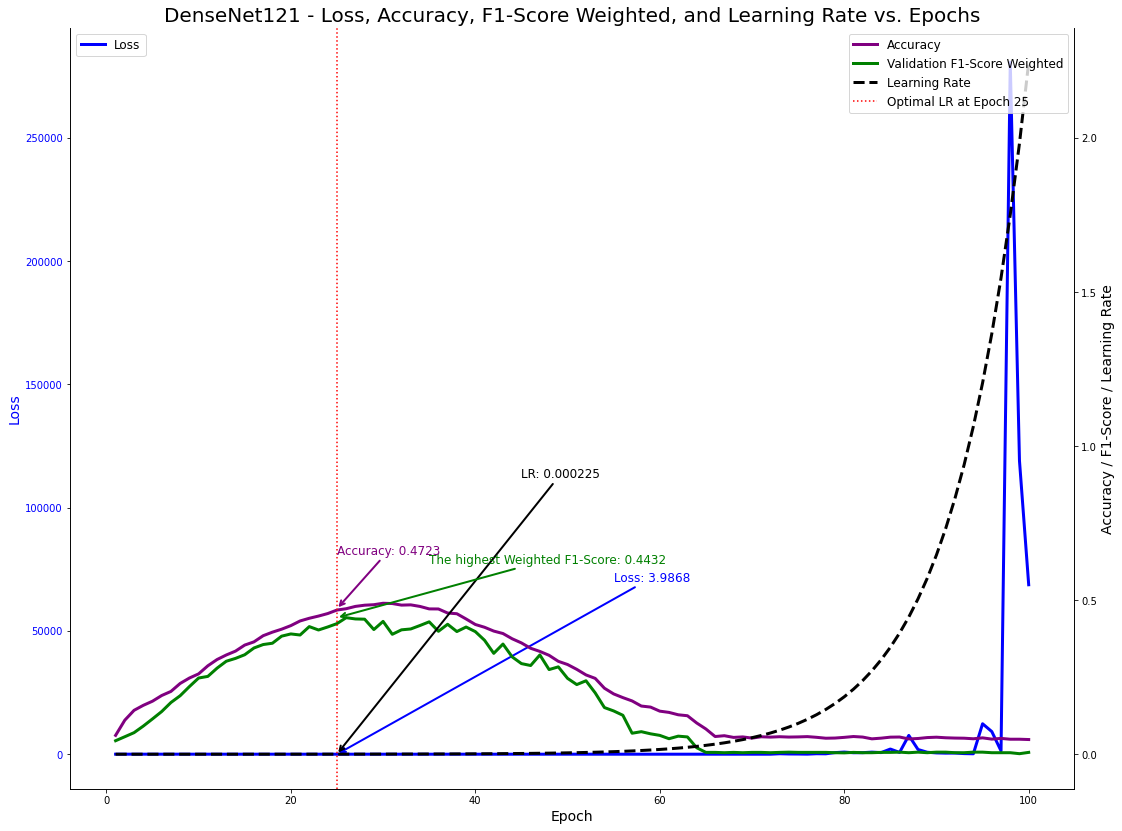

In [18]:
from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *

# 6. Display Learning Rate, Loss, Accuracy, and F1-Score Weighted all together across Epochs
display_lr_loss_accuracy_f1_across_epochs(history, model_name=model_name)

 #####  DenseNet121 - Load  Training History for Verification Optional

In [29]:
import pickle
import pandas as pd
import importlib

from src.modeling_image import lr_optimization
importlib.reload(lr_optimization)
importlib.reload(config)

# --- Configuration ---
model_name = 'DenseNet121'
step_name = 'Step4'  # Adjust as needed
optimal_epoch = 25   # Epoch visually identified from the F1/Loss/Learning Rate plot
window = 2          # Epochs before and after for inspection

# --- Load history from .pkl file ---
history_filepath = MODEL_DIR / f'{step_name}_{model_name}_history.pkl'
with open(history_filepath, 'rb') as history_file:
    saved_history = pickle.load(history_file)

# --- Convert to DataFrame ---
history_df = pd.DataFrame(saved_history)

# --- Save as CSV for reference ---
csv_history_filepath = MODEL_DIR / f'{step_name}_{model_name}_history.csv'
history_df.to_csv(csv_history_filepath, index=False)

# --- Console Info ---
print("Loaded history keys:", saved_history.keys())
print(f"History shape: {history_df.shape}")
print(f"CSV saved to: {csv_history_filepath}")

# --- Optional Preview ---
print("First rows:")
display(history_df.head(2))

print("Last rows:")
display(history_df.tail(2))

# --- Epoch Verification Window ---
start = max(0, optimal_epoch - window)
end = min(len(history_df), optimal_epoch + window + 1)

print(f"Verifying values around optimal epoch**{optimal_epoch}** (window ±{window}):")
display(history_df.iloc[start:end])

# --- Wrap history in dummy object if needed for plotting functions ---
class History:
    def __init__(self, history_dict):
        self.history = history_dict

history = History(saved_history)



Loaded history keys: Index(['loss', 'accuracy', 'val_loss', 'val_accuracy', 'val_f1_score', 'lr'], dtype='object')
History shape: (100, 6)
CSV saved to: D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\models\image\lr_optimization\Step4_DenseNet121_history.csv
First rows:


,loss,accuracy,val_loss,val_accuracy,val_f1_score,lr
0,15.674083,0.061240,13.062764,0.131625,0.043758,0.000010
1,14.598106,0.110555,12.513144,0.152238,0.056763,0.000011


Last rows:


,loss,accuracy,val_loss,val_accuracy,val_f1_score,lr
98,119050.054688,0.048653,87501.804688,0.029446,0.001685,1.982884
99,68737.148438,0.047623,54276.289062,0.055948,0.005929,2.245698


Verifying values around optimal epoch**25** (window ±2):


,loss,accuracy,val_loss,val_accuracy,val_f1_score,lr
23,4.523260,0.456573,3.889962,0.434335,0.413038,0.000175
24,4.244707,0.467908,3.638079,0.446408,0.423853,0.000198
25,3.986789,0.472251,3.408457,0.459658,0.443166,0.000225
26,3.756163,0.479759,3.219086,0.458186,0.439064,0.000254
27,3.562821,0.483660,3.036239,0.457303,0.438283,0.000288


 #### Step 3: DenseNet121 -  Analyze the Results and Identify the Optimal Learning Rate

Based on the graph showing the **Loss**, **Accuracy**, **F1-Score Weighted**, and **Learning Rate** against **Epochs** for the **DenseNet121** model, we can derive the following insights:

**Graph Analysis and Annotations**

- **Annotations on Graph**:  
  The plot clearly marks the **Highest Weighted F1-Score** of `0.4432` (green), the corresponding **Accuracy** of `0.4723` (purple), the **Loss** of `3.9868` (blue), and the **Learning Rate** of `0.000225` (black dashed). The **Optimal Epoch** is highlighted at **Epoch 25** using a vertical red line.

- **Stability Before the Peak**:  
  Prior to **Epoch 25**, all major metrics (loss, accuracy, f1-score) follow a relatively smooth and improving trajectory, suggesting steady model learning within a stable learning rate range.

- **Post-Peak Instability**:  
  Beyond this point, we observe that **Loss** begins to rise, and **Accuracy** along with **F1-Score** decline. This coincides with a sharper increase in **Learning Rate**, indicating the model becomes unstable as the learning rate exceeds the optimal range.

- **Conclusion**:  
  From this graph, we infer that the **optimal learning rate** for the **DenseNet121** model is approximately **0.000225**, corresponding to **Epoch 25**, where the model achieved its best balance between loss, accuracy, and F1-Score before instability set in.

 ### 5.3 MobileNetV2 - LR Range Test and Performance Analysis

 #### Step 1: MobileNetV2 -   Build and Train with Learning Rate Range Test

In [9]:
%%time

model_name = 'MobileNetV2' 

# Initialize the model using the build_model function.
model = build_model(
    model_name=model_name,
    input_shape=in_shape_224,
    num_classes=NUM_CLASSES,
    unfreeze_last_layers_count=None  
)

# Calling the train_model_and_save function 
model, history = train_model_and_save(
    model=model,
    train_data=train_gen_224x224,   # The subset of training data
    val_data=valid_gen_224x224,     # The subset of validation data
    epochs=EPOCHS,                 
    batch_size=BATCH_SIZE,         
    class_weight_dict=class_weight_dict,  # Apply class weights 
    learning_rate=LEARNING_RATE,        # Learning rate
    model_name=model_name,              # The model name for saving
    save_model_dir=MODEL_DIR,           # Directory to save the model and checkpoints
    step_name=STEP_NAME,                # The current step name (e.g., 'Step2', 'Step3') for proper file naming
    lr_scheduler=lr_scheduler           # Apply the Learning Rate Scheduler
)


[INFO] : Starting at epoch: 0, learning_rate: 9.999999747378752e-06
Epoch 1/100
213/213 [==============================] - ETA: 0s - loss: 16.1115 - accuracy: 0.0750
Epoch 1: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 90s 375ms/step - loss: 16.1115 - accuracy: 0.0750 - val_loss: 13.7784 - val_accuracy: 0.1440 - val_f1_score: 0.0580 - lr: 1.0000e-05
[INFO] : Learning rate updated from: 9.999999747378752e-06 to: 1.132541315152812e-05 at epoch 1
Epoch 2/100
213/213 [==============================] - ETA: 0s - loss: 15.2679 - accuracy: 0.1286
Epoch 2: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 76s 357ms/step - loss: 15.2679 - accuracy: 0.1286 - val_loss: 13.4619 - val_accuracy: 0.1567 - val_f1_score: 0.0631 - lr: 1.1325e-05
[INFO] : Learning rate updated from: 1.1325412742735352e-05 to: 1.2826498305280606e-05 at epoch 2
Epoch 3/100


[INFO] : Learning rate updated from: 6.468607898568735e-05 to: 7.325965428215231e-05 at epoch 16
Epoch 17/100
213/213 [==============================] - ETA: 0s - loss: 8.0331 - accuracy: 0.4251
Epoch 17: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 75s 355ms/step - loss: 8.0331 - accuracy: 0.4251 - val_loss: 7.2033 - val_accuracy: 0.4128 - val_f1_score: 0.3956 - lr: 7.3260e-05
[INFO] : Learning rate updated from: 7.325965270865709e-05 to: 8.29695852083491e-05 at epoch 17
Epoch 18/100
213/213 [==============================] - ETA: 0s - loss: 7.4900 - accuracy: 0.4416
Epoch 18: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 76s 358ms/step - loss: 7.4900 - accuracy: 0.4416 - val_loss: 6.6834 - val_accuracy: 0.4320 - val_f1_score: 0.4100 - lr: 8.2970e-05
[INFO] : Learning rate updated from: 8.296958549181e-05 to: 9.396648314954697e-05 a

[INFO] : Learning rate updated from: 0.00047388795064762235 to: 0.0005366976945540477 at epoch 32
Epoch 33/100
213/213 [==============================] - ETA: 0s - loss: 3.0676 - accuracy: 0.5169
Epoch 33: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 76s 356ms/step - loss: 3.0676 - accuracy: 0.5169 - val_loss: 2.8299 - val_accuracy: 0.4526 - val_f1_score: 0.4316 - lr: 5.3670e-04
[INFO] : Learning rate updated from: 0.0005366976838558912 to: 0.000607832312829723 at epoch 33
Epoch 34/100
213/213 [==============================] - ETA: 0s - loss: 3.1119 - accuracy: 0.5035
Epoch 34: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 76s 357ms/step - loss: 3.1119 - accuracy: 0.5035 - val_loss: 2.9239 - val_accuracy: 0.4273 - val_f1_score: 0.4082 - lr: 6.0783e-04
[INFO] : Learning rate updated from: 0.0006078323349356651 to: 0.00068839520696455

213/213 [==============================] - ETA: 0s - loss: 4.0586 - accuracy: 0.2988
Epoch 49: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 77s 359ms/step - loss: 4.0586 - accuracy: 0.2988 - val_loss: 3.0834 - val_accuracy: 0.2812 - val_f1_score: 0.2148 - lr: 0.0039
[INFO] : Learning rate updated from: 0.003931828774511814 to: 0.004452958509942656 at epoch 49
Epoch 50/100
213/213 [==============================] - ETA: 0s - loss: 4.0947 - accuracy: 0.2826
Epoch 50: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 76s 356ms/step - loss: 4.0947 - accuracy: 0.2826 - val_loss: 2.9738 - val_accuracy: 0.3024 - val_f1_score: 0.2586 - lr: 0.0045
[INFO] : Learning rate updated from: 0.004452958703041077 to: 0.005043159487171359 at epoch 50
Epoch 51/100
213/213 [==============================] - ETA: 0s - loss: 4.1209 - accuracy: 0.2743
Epoch 51:

213/213 [==============================] - ETA: 0s - loss: 460.7735 - accuracy: 0.0546
Epoch 81: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 76s 357ms/step - loss: 460.7735 - accuracy: 0.0546 - val_loss: 328.8895 - val_accuracy: 0.0595 - val_f1_score: 0.0067 - lr: 0.2110
[INFO] : Learning rate updated from: 0.2110203355550766 to: 0.2389892566231048 at epoch 81
Epoch 82/100
213/213 [==============================] - ETA: 0s - loss: 726.1534 - accuracy: 0.0559
Epoch 82: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 76s 357ms/step - loss: 726.1534 - accuracy: 0.0559 - val_loss: 419.0191 - val_accuracy: 0.0506 - val_f1_score: 0.0049 - lr: 0.2390
[INFO] : Learning rate updated from: 0.23898926377296448 to: 0.27066520700332414 at epoch 82
Epoch 83/100
213/213 [==============================] - ETA: 0s - loss: 3890.6208 - accuracy: 0.0522


213/213 [==============================] - ETA: 0s - loss: 11079.6279 - accuracy: 0.0521
Epoch 97: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 77s 362ms/step - loss: 11079.6279 - accuracy: 0.0521 - val_loss: 8572.8047 - val_accuracy: 0.0294 - val_f1_score: 0.0017 - lr: 1.5459
[INFO] : Learning rate updated from: 1.5459277629852295 to: 1.7508270317357235 at epoch 97
Epoch 98/100
213/213 [==============================] - ETA: 0s - loss: 6894.7422 - accuracy: 0.0520
Epoch 98: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 76s 356ms/step - loss: 6894.7422 - accuracy: 0.0520 - val_loss: 5557.3726 - val_accuracy: 0.0559 - val_f1_score: 0.0059 - lr: 1.7508
[INFO] : Learning rate updated from: 1.7508270740509033 to: 1.9828839491270713 at epoch 98
Epoch 99/100
213/213 [==============================] - ETA: 0s - loss: 16154.6689 - accuracy: 

 #### Step 2:  MobileNetV2 -  Plot Learning Rate vs. Loss, F1-Score Weighted, Accuracy

Y-axis range for Loss 3.057347297668457 to 185039.6875
Y-axis range for Loss - loss_scale 92518.31507635117


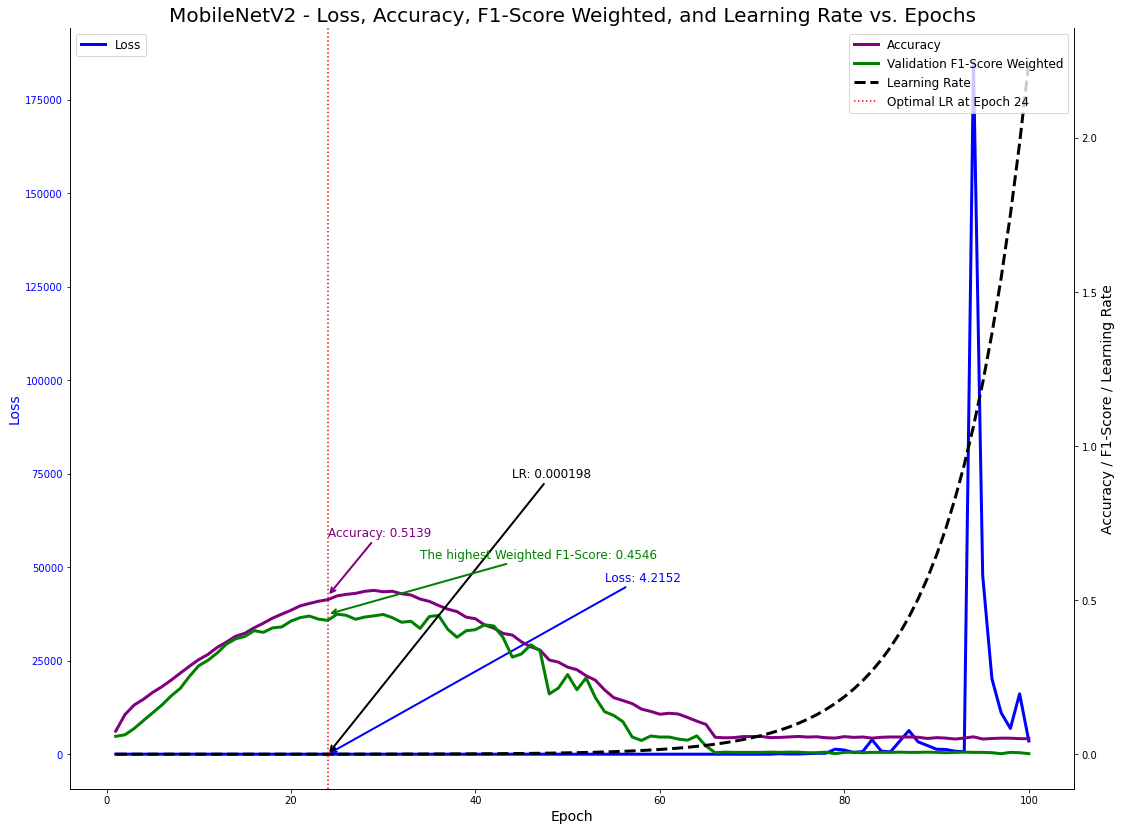

In [11]:
from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *

# 6. Display Learning Rate, Loss, Accuracy, and F1-Score Weighted all together across Epochs
display_lr_loss_accuracy_f1_across_epochs(history, model_name=model_name)

  #####  MobileNetV2 - Load Training History for Verification - Optional

In [12]:
import pickle
import pandas as pd
import importlib

from src.modeling_image import lr_optimization
importlib.reload(lr_optimization)
importlib.reload(config)

# --- Configuration ---
model_name = 'MobileNetV2'
step_name = 'Step4'  # Adjust as needed
optimal_epoch = 24   # Epoch visually identified from the F1/Loss/Learning Rate plot
window = 2          # Epochs before and after for inspection

# --- Load history from .pkl file ---
history_filepath = MODEL_DIR / f'{step_name}_{model_name}_history.pkl'
with open(history_filepath, 'rb') as history_file:
    saved_history = pickle.load(history_file)

# --- Convert to DataFrame ---
history_df = pd.DataFrame(saved_history)

# --- Save as CSV for reference ---
csv_history_filepath = MODEL_DIR / f'{step_name}_{model_name}_history.csv'
history_df.to_csv(csv_history_filepath, index=False)

# --- Console Info ---
print("Loaded history keys:", saved_history.keys())
print(f"History shape: {history_df.shape}")
print(f"CSV saved to: {csv_history_filepath}")

# --- Optional Preview ---
print("First rows:")
display(history_df.head(2))

print("Last rows:")
display(history_df.tail(2))

# --- Epoch Verification Window ---
start = max(0, optimal_epoch - window)
end = min(len(history_df), optimal_epoch + window + 1)

print(f"Verifying values around optimal epoch**{optimal_epoch}** (window ±{window}):")
display(history_df.iloc[start:end])

# --- Wrap history in dummy object if needed for plotting functions ---
class History:
    def __init__(self, history_dict):
        self.history = history_dict

history = History(saved_history)



Loaded history keys: Index(['loss', 'accuracy', 'val_loss', 'val_accuracy', 'val_f1_score', 'lr'], dtype='object')
History shape: (100, 6)
CSV saved to: D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\models\image\lr_optimization\Step4_MobileNetV2_history.csv
First rows:


,loss,accuracy,val_loss,val_accuracy,val_f1_score,lr
0,16.111481,0.075004,13.778440,0.143993,0.057972,0.000010
1,15.267864,0.128588,13.461857,0.156655,0.063058,0.000011


Last rows:


,loss,accuracy,val_loss,val_accuracy,val_f1_score,lr
98,16154.668945,0.050493,4468.429688,0.050648,0.004883,1.982884
99,3533.552490,0.050346,2897.807129,0.030624,0.001820,2.245698


Verifying values around optimal epoch**24** (window ±2):


,loss,accuracy,val_loss,val_accuracy,val_f1_score,lr
22,4.998646,0.496614,4.489231,0.458481,0.438291,0.000155
23,4.598824,0.501767,4.169382,0.450530,0.434489,0.000175
24,4.215171,0.513911,3.814817,0.469081,0.454579,0.000198
25,3.892552,0.518843,3.565616,0.466726,0.450872,0.000225
26,3.634284,0.522082,3.390539,0.447585,0.437934,0.000254


#### Step 3:  MobileNetV2 -  Analyze the Results and Identify the Optimal Learning Rate

Based on the graph showing the **Loss**, **Accuracy**, **F1-Score Weighted**, and **Learning Rate** against **Epochs** for the **MobileNetV2** model, we can derive the following insights:

**Graph Analysis and Annotations**

- **Graph Annotations**:  
  The graph highlights key values at **Epoch 24**, including the **Highest Weighted F1-Score** of `0.4546` (green), the corresponding **Accuracy** of `0.5139` (purple), **Loss** of `4.2152` (blue), and the **Learning Rate** of `0.000198` (black dashed). This optimal point is indicated with a vertical red line.

- **Before the Peak**:  
  Up to **Epoch 24**, metrics evolve smoothly. Accuracy and F1-score improve steadily while the loss decreases—signs of efficient learning under a well-controlled learning rate.

- **After the Peak**:  
  Post-epoch 24, the **loss spikes** and both **accuracy** and **F1-score** drop, as the learning rate continues to rise, suggesting that the model is diverging due to an overly aggressive learning rate.

- **Conclusion**:  
  The **optimal learning rate** for **MobileNetV2** is around **0.000198**, observed at **Epoch 24**, which marks the balance point before performance begins to degrade.


 ### 5.4 InceptionResNetV2 - LR Range Test and Performance Analysis

#### Step 1: InceptionResNetV2 -  Build and Train  with Learning Rate Range Test

In [9]:
%%time

model_name = 'InceptionResNetV2' 

# Initialize the model using the build_model function.
model = build_model(
    model_name=model_name,
    input_shape=in_shape_299,
    num_classes=NUM_CLASSES,
    unfreeze_last_layers_count=None  
)

# Calling the train_model_and_save function 
model, history = train_model_and_save(
    model=model,
    train_data=train_gen_299x299,   # The subset of training data
    val_data=valid_gen_299x299,     # The subset of validation data
    epochs=EPOCHS,                 
    batch_size=BATCH_SIZE,         
    class_weight_dict=class_weight_dict,  # Apply class weights 
    learning_rate=LEARNING_RATE,        # Learning rate
    model_name=model_name,              # The model name for saving
    save_model_dir=MODEL_DIR,           # Directory to save the model and checkpoints
    step_name=STEP_NAME,                # The current step name (e.g., 'Step2', 'Step3') for proper file naming
    lr_scheduler=lr_scheduler           # Apply the Learning Rate Scheduler
)


[INFO] : Starting at epoch: 0, learning_rate: 9.999999747378752e-06
Epoch 1/100
213/213 [==============================] - ETA: 0s - loss: 16.2549 - accuracy: 0.0875
Epoch 1: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 130s 534ms/step - loss: 16.2549 - accuracy: 0.0875 - val_loss: 13.9814 - val_accuracy: 0.1490 - val_f1_score: 0.0531 - lr: 1.0000e-05
[INFO] : Learning rate updated from: 9.999999747378752e-06 to: 1.132541315152812e-05 at epoch 1
Epoch 2/100
213/213 [==============================] - ETA: 0s - loss: 15.3480 - accuracy: 0.1458
Epoch 2: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 128s 603ms/step - loss: 15.3480 - accuracy: 0.1458 - val_loss: 13.5344 - val_accuracy: 0.1696 - val_f1_score: 0.0647 - lr: 1.1325e-05
[INFO] : Learning rate updated from: 1.1325412742735352e-05 to: 1.2826498305280606e-05 at epoch 2
Epoch 3/10

[INFO] : Learning rate updated from: 6.468607898568735e-05 to: 7.325965428215231e-05 at epoch 16
Epoch 17/100
213/213 [==============================] - ETA: 0s - loss: 7.1597 - accuracy: 0.4317
Epoch 17: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 162s 761ms/step - loss: 7.1597 - accuracy: 0.4317 - val_loss: 6.2278 - val_accuracy: 0.4320 - val_f1_score: 0.4062 - lr: 7.3260e-05
[INFO] : Learning rate updated from: 7.325965270865709e-05 to: 8.29695852083491e-05 at epoch 17
Epoch 18/100
213/213 [==============================] - ETA: 0s - loss: 6.6747 - accuracy: 0.4377
Epoch 18: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 162s 761ms/step - loss: 6.6747 - accuracy: 0.4377 - val_loss: 5.7465 - val_accuracy: 0.4426 - val_f1_score: 0.4156 - lr: 8.2970e-05
[INFO] : Learning rate updated from: 8.296958549181e-05 to: 9.396648314954697e-05

[INFO] : Learning rate updated from: 0.00047388795064762235 to: 0.0005366976945540477 at epoch 32
Epoch 33/100
213/213 [==============================] - ETA: 0s - loss: 3.1384 - accuracy: 0.4482
Epoch 33: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 160s 752ms/step - loss: 3.1384 - accuracy: 0.4482 - val_loss: 2.5358 - val_accuracy: 0.4261 - val_f1_score: 0.3958 - lr: 5.3670e-04
[INFO] : Learning rate updated from: 0.0005366976838558912 to: 0.000607832312829723 at epoch 33
Epoch 34/100
213/213 [==============================] - ETA: 0s - loss: 3.1724 - accuracy: 0.4376
Epoch 34: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 160s 751ms/step - loss: 3.1724 - accuracy: 0.4376 - val_loss: 2.4686 - val_accuracy: 0.4320 - val_f1_score: 0.4081 - lr: 6.0783e-04
[INFO] : Learning rate updated from: 0.0006078323349356651 to: 0.000688395206964

213/213 [==============================] - ETA: 0s - loss: 4.1338 - accuracy: 0.2699
Epoch 49: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 160s 753ms/step - loss: 4.1338 - accuracy: 0.2699 - val_loss: 3.0413 - val_accuracy: 0.2794 - val_f1_score: 0.2249 - lr: 0.0039
[INFO] : Learning rate updated from: 0.003931828774511814 to: 0.004452958509942656 at epoch 49
Epoch 50/100
213/213 [==============================] - ETA: 0s - loss: 4.1265 - accuracy: 0.2585
Epoch 50: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 160s 752ms/step - loss: 4.1265 - accuracy: 0.2585 - val_loss: 3.1762 - val_accuracy: 0.2686 - val_f1_score: 0.2308 - lr: 0.0045
[INFO] : Learning rate updated from: 0.004452958703041077 to: 0.005043159487171359 at epoch 50
Epoch 51/100
213/213 [==============================] - ETA: 0s - loss: 4.3092 - accuracy: 0.2433
Epoch 5

213/213 [==============================] - ETA: 0s - loss: 5.2050 - accuracy: 0.0977
Epoch 65: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 162s 762ms/step - loss: 5.2050 - accuracy: 0.0977 - val_loss: 6.6831 - val_accuracy: 0.1045 - val_f1_score: 0.0220 - lr: 0.0288
[INFO] : Learning rate updated from: 0.028804441913962364 to: 0.0326222200971167 at epoch 65
Epoch 66/100
213/213 [==============================] - ETA: 0s - loss: 5.3081 - accuracy: 0.0674
Epoch 66: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 164s 772ms/step - loss: 5.3081 - accuracy: 0.0674 - val_loss: 3.8468 - val_accuracy: 0.1116 - val_f1_score: 0.0242 - lr: 0.0326
[INFO] : Learning rate updated from: 0.03262222185730934 to: 0.03694601205199303 at epoch 66
Epoch 67/100
213/213 [==============================] - ETA: 0s - loss: 5.0782 - accuracy: 0.0595
Epoch 67: E

213/213 [==============================] - ETA: 0s - loss: 1064.8488 - accuracy: 0.0552
Epoch 81: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 165s 776ms/step - loss: 1064.8488 - accuracy: 0.0552 - val_loss: 495.4899 - val_accuracy: 0.0506 - val_f1_score: 0.0049 - lr: 0.2110
[INFO] : Learning rate updated from: 0.2110203355550766 to: 0.2389892566231048 at epoch 81
Epoch 82/100
213/213 [==============================] - ETA: 0s - loss: 336.2963 - accuracy: 0.0560
Epoch 82: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 167s 784ms/step - loss: 336.2963 - accuracy: 0.0560 - val_loss: 269.6476 - val_accuracy: 0.0595 - val_f1_score: 0.0067 - lr: 0.2390
[INFO] : Learning rate updated from: 0.23898926377296448 to: 0.27066520700332414 at epoch 82
Epoch 83/100
213/213 [==============================] - ETA: 0s - loss: 2130.5381 - accuracy: 0.0

213/213 [==============================] - ETA: 0s - loss: 53649.8242 - accuracy: 0.0486
Epoch 97: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 165s 773ms/step - loss: 53649.8242 - accuracy: 0.0486 - val_loss: 40107.5000 - val_accuracy: 0.0294 - val_f1_score: 0.0017 - lr: 1.5459
[INFO] : Learning rate updated from: 1.5459277629852295 to: 1.7508270317357235 at epoch 97
Epoch 98/100
213/213 [==============================] - ETA: 0s - loss: 31948.4395 - accuracy: 0.0523
Epoch 98: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 162s 760ms/step - loss: 31948.4395 - accuracy: 0.0523 - val_loss: 25504.7129 - val_accuracy: 0.0506 - val_f1_score: 0.0049 - lr: 1.7508
[INFO] : Learning rate updated from: 1.7508270740509033 to: 1.9828839491270713 at epoch 98
Epoch 99/100
213/213 [==============================] - ETA: 0s - loss: 287117.0312 - acc

#### Step 2:  InceptionResNetV2 - Visualizing the Learning Rate, Loss, Accuracy, and F1-Score for Model: Xception across Epochs

##### InceptionResNetV2 - Display Learning Rate, Loss, Accuracy, and F1-Score Weighted across epochs

Y-axis range for Loss 3.119741916656494 to 448695.71875
Y-axis range for Loss - loss_scale 224346.29950404167


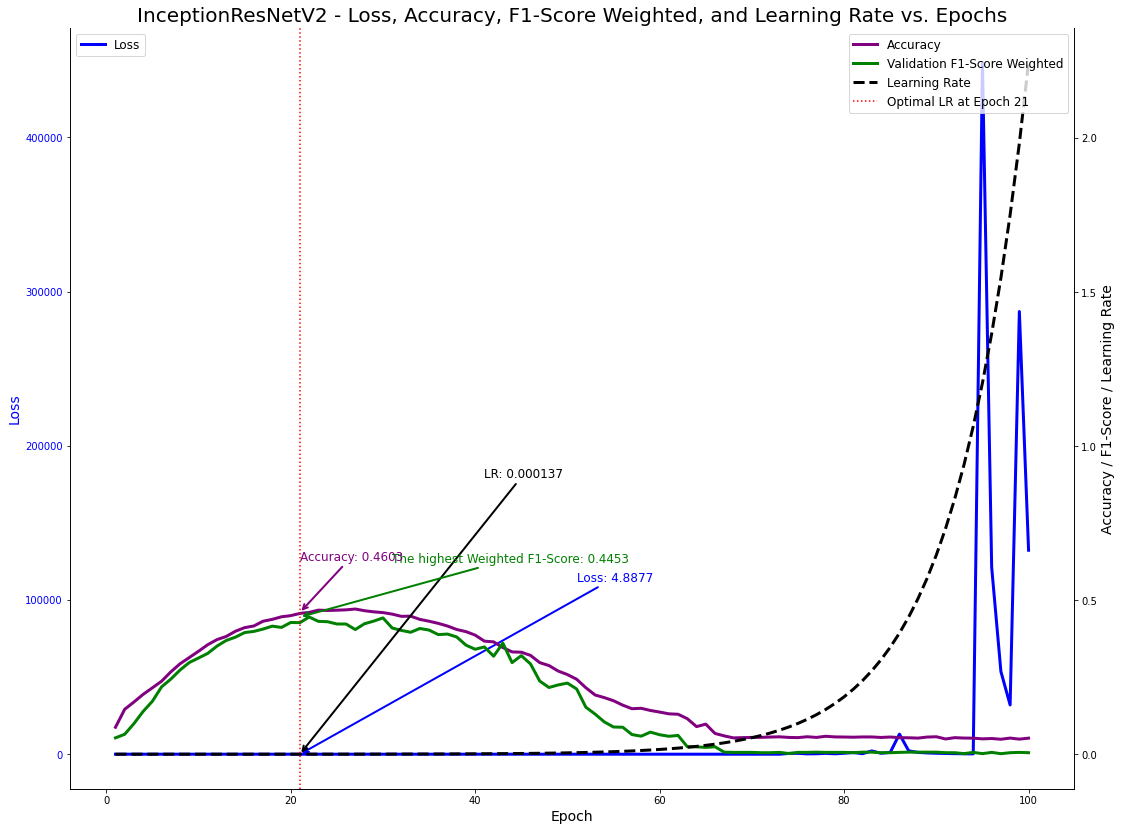

In [11]:
from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *

# 6. Display Learning Rate, Loss, Accuracy, and F1-Score Weighted all together across Epochs
display_lr_loss_accuracy_f1_across_epochs(history, model_name=model_name)

#####  InceptionResNetV2 - Load  Training History for Verification - Optional  

In [12]:
import pickle
import pandas as pd
import importlib

from src.modeling_image import lr_optimization
importlib.reload(lr_optimization)
importlib.reload(config)

# --- Configuration ---
model_name = 'InceptionResNetV2'
step_name = 'Step4'  # Adjust as needed
optimal_epoch = 21   # Epoch visually identified from the F1/Loss/Learning Rate plot
window = 2          # Epochs before and after for inspection

# --- Load history from .pkl file ---
history_filepath = MODEL_DIR / f'{step_name}_{model_name}_history.pkl'
with open(history_filepath, 'rb') as history_file:
    saved_history = pickle.load(history_file)

# --- Convert to DataFrame ---
history_df = pd.DataFrame(saved_history)

# --- Save as CSV for reference ---
csv_history_filepath = MODEL_DIR / f'{step_name}_{model_name}_history.csv'
history_df.to_csv(csv_history_filepath, index=False)

# --- Console Info ---
print("Loaded history keys:", saved_history.keys())
print(f"History shape: {history_df.shape}")
print(f"CSV saved to: {csv_history_filepath}")

# --- Optional Preview ---
print("First rows:")
display(history_df.head(2))

print("Last rows:")
display(history_df.tail(2))

# --- Epoch Verification Window ---
start = max(0, optimal_epoch - window)
end = min(len(history_df), optimal_epoch + window + 1)

print(f"Verifying values around optimal epoch**{optimal_epoch}** (window ±{window}):")
display(history_df.iloc[start:end])

# --- Wrap history in dummy object if needed for plotting functions ---
class History:
    def __init__(self, history_dict):
        self.history = history_dict

history = History(saved_history)



Loaded history keys: Index(['loss', 'accuracy', 'val_loss', 'val_accuracy', 'val_f1_score', 'lr'], dtype='object')
History shape: (100, 6)
CSV saved to: D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\models\image\lr_optimization\Step4_InceptionResNetV2_history.csv
First rows:


,loss,accuracy,val_loss,val_accuracy,val_f1_score,lr
0,16.254902,0.087517,13.981371,0.148999,0.053072,0.000010
1,15.347995,0.145812,13.534360,0.169611,0.064703,0.000011


Last rows:


,loss,accuracy,val_loss,val_accuracy,val_f1_score,lr
98,287117.03125,0.048947,227224.078125,0.055948,0.005929,1.982884
99,132271.65625,0.052112,77820.242188,0.050648,0.004883,2.245698


Verifying values around optimal epoch**21** (window ±2):


,loss,accuracy,val_loss,val_accuracy,val_f1_score,lr
19,5.723176,0.449801,4.857788,0.451119,0.427568,0.000106
20,5.292440,0.457015,4.474484,0.443463,0.427061,0.000121
21,4.887733,0.460327,4.054545,0.463486,0.445309,0.000137
22,4.511390,0.467687,3.743286,0.456419,0.431231,0.000155
23,4.176760,0.466583,3.499541,0.437574,0.430089,0.000175


#### Step 3: InceptionResNetV2 -  Analyze the Results and Identify the Optimal Learning Rate

Based on the graph showing the **Loss**, **Accuracy**, **F1-Score Weighted**, and **Learning Rate** against **Epochs** for the **InceptionV3** model, we can derive the following insights:

**Graph Analysis and Annotations**

- **Graph Annotations**:  
  At **Epoch 21**, the model achieves its highest **Weighted F1-Score** of `0.4453`, with an **Accuracy** of `0.4603`, a **Loss** of `4.8877`, and a **Learning Rate** of `0.000137`. This point is marked by a vertical red line.

- **Before the Peak**:  
  The metrics show a consistent learning curve with improving accuracy and F1-score, and decreasing loss.

- **After the Peak**:  
  Post-Epoch 21, the **Loss** increases and both **Accuracy** and **F1-Score** decline, indicating overfitting or learning instability due to an excessive learning rate.

- **Conclusion**:  
  The **optimal learning rate** for **InceptionV3** appears to be **0.000137**, corresponding to **Epoch 21**, where the model performs best before performance drops.


 ### 5.5 Xception - LR Range Test and Performance Analysis

#### Step 1: Xception -  Build and Train with Learning Rate Range Test

In [30]:
%%time

model_name = 'Xception' 

# Initialize the model using the build_model function.
model = build_model(
    model_name=model_name,
    input_shape=in_shape_299,
    num_classes=NUM_CLASSES,
    unfreeze_last_layers_count=None  
)

# Calling the train_model_and_save function 
model, history = train_model_and_save(
    model=model,
    train_data=train_gen_299x299,   # The subset of training data
    val_data=valid_gen_299x299,     # The subset of validation data
    epochs=EPOCHS,                 
    batch_size=BATCH_SIZE,         
    class_weight_dict=class_weight_dict,  # Apply class weights 
    learning_rate=LEARNING_RATE,        # Learning rate
    model_name=model_name,              # The model name for saving
    save_model_dir=MODEL_DIR,           # Directory to save the model and checkpoints
    step_name=STEP_NAME,                # The current step name (e.g., 'Step2', 'Step3') for proper file naming
    lr_scheduler=lr_scheduler           # Apply the Learning Rate Scheduler
)


[INFO] : Starting at epoch: 0, learning_rate: 9.999999747378752e-06
Epoch 1/100
213/213 [==============================] - ETA: 0s - loss: 16.8179 - accuracy: 0.0721
Epoch 1: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 111s 502ms/step - loss: 16.8179 - accuracy: 0.0721 - val_loss: 14.3772 - val_accuracy: 0.1328 - val_f1_score: 0.0569 - lr: 1.0000e-05
[INFO] : Learning rate updated from: 9.999999747378752e-06 to: 1.132541315152812e-05 at epoch 1
Epoch 2/100
213/213 [==============================] - ETA: 0s - loss: 15.8213 - accuracy: 0.1300
Epoch 2: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 116s 543ms/step - loss: 15.8213 - accuracy: 0.1300 - val_loss: 13.8594 - val_accuracy: 0.1466 - val_f1_score: 0.0531 - lr: 1.1325e-05
[INFO] : Learning rate updated from: 1.1325412742735352e-05 to: 1.2826498305280606e-05 at epoch 2
Epoch 3/10

[INFO] : Learning rate updated from: 6.468607898568735e-05 to: 7.325965428215231e-05 at epoch 16
Epoch 17/100
213/213 [==============================] - ETA: 0s - loss: 5.9889 - accuracy: 0.4360
Epoch 17: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 155s 727ms/step - loss: 5.9889 - accuracy: 0.4360 - val_loss: 5.1341 - val_accuracy: 0.4326 - val_f1_score: 0.4011 - lr: 7.3260e-05
[INFO] : Learning rate updated from: 7.325965270865709e-05 to: 8.29695852083491e-05 at epoch 17
Epoch 18/100
213/213 [==============================] - ETA: 0s - loss: 5.5100 - accuracy: 0.4457
Epoch 18: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 152s 715ms/step - loss: 5.5100 - accuracy: 0.4457 - val_loss: 4.6896 - val_accuracy: 0.4458 - val_f1_score: 0.4142 - lr: 8.2970e-05
[INFO] : Learning rate updated from: 8.296958549181e-05 to: 9.396648314954697e-05

[INFO] : Learning rate updated from: 0.00047388795064762235 to: 0.0005366976945540477 at epoch 32
Epoch 33/100
213/213 [==============================] - ETA: 0s - loss: 3.1201 - accuracy: 0.4558
Epoch 33: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 143s 672ms/step - loss: 3.1201 - accuracy: 0.4558 - val_loss: 2.5589 - val_accuracy: 0.4323 - val_f1_score: 0.4230 - lr: 5.3670e-04
[INFO] : Learning rate updated from: 0.0005366976838558912 to: 0.000607832312829723 at epoch 33
Epoch 34/100
213/213 [==============================] - ETA: 0s - loss: 3.1815 - accuracy: 0.4508
Epoch 34: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 139s 654ms/step - loss: 3.1815 - accuracy: 0.4508 - val_loss: 2.6126 - val_accuracy: 0.4226 - val_f1_score: 0.3893 - lr: 6.0783e-04
[INFO] : Learning rate updated from: 0.0006078323349356651 to: 0.000688395206964

213/213 [==============================] - ETA: 0s - loss: 4.0984 - accuracy: 0.3021
Epoch 49: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 141s 662ms/step - loss: 4.0984 - accuracy: 0.3021 - val_loss: 3.0681 - val_accuracy: 0.3218 - val_f1_score: 0.2582 - lr: 0.0039
[INFO] : Learning rate updated from: 0.003931828774511814 to: 0.004452958509942656 at epoch 49
Epoch 50/100
213/213 [==============================] - ETA: 0s - loss: 4.1367 - accuracy: 0.2932
Epoch 50: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 142s 667ms/step - loss: 4.1367 - accuracy: 0.2932 - val_loss: 3.0681 - val_accuracy: 0.3189 - val_f1_score: 0.2642 - lr: 0.0045
[INFO] : Learning rate updated from: 0.004452958703041077 to: 0.005043159487171359 at epoch 50
Epoch 51/100
213/213 [==============================] - ETA: 0s - loss: 4.0950 - accuracy: 0.2876
Epoch 5

213/213 [==============================] - ETA: 0s - loss: 30.4452 - accuracy: 0.0554
Epoch 81: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 139s 652ms/step - loss: 30.4452 - accuracy: 0.0554 - val_loss: 14.9030 - val_accuracy: 0.0506 - val_f1_score: 0.0049 - lr: 0.2110
[INFO] : Learning rate updated from: 0.2110203355550766 to: 0.2389892566231048 at epoch 81
Epoch 82/100
213/213 [==============================] - ETA: 0s - loss: 1122.4065 - accuracy: 0.0566
Epoch 82: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 140s 660ms/step - loss: 1122.4065 - accuracy: 0.0566 - val_loss: 562.0673 - val_accuracy: 0.0559 - val_f1_score: 0.0059 - lr: 0.2390
[INFO] : Learning rate updated from: 0.23898926377296448 to: 0.27066520700332414 at epoch 82
Epoch 83/100
213/213 [==============================] - ETA: 0s - loss: 1893.2317 - accuracy: 0.0528

213/213 [==============================] - ETA: 0s - loss: 57304.5664 - accuracy: 0.0517
Epoch 97: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 139s 651ms/step - loss: 57304.5664 - accuracy: 0.0517 - val_loss: 32514.1133 - val_accuracy: 0.0595 - val_f1_score: 0.0067 - lr: 1.5459
[INFO] : Learning rate updated from: 1.5459277629852295 to: 1.7508270317357235 at epoch 97
Epoch 98/100
213/213 [==============================] - ETA: 0s - loss: 22390.2207 - accuracy: 0.0511
Epoch 98: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 138s 646ms/step - loss: 22390.2207 - accuracy: 0.0511 - val_loss: 15471.2529 - val_accuracy: 0.0506 - val_f1_score: 0.0049 - lr: 1.7508
[INFO] : Learning rate updated from: 1.7508270740509033 to: 1.9828839491270713 at epoch 98
Epoch 99/100
213/213 [==============================] - ETA: 0s - loss: 11644.8076 - accu

#### Step 2:  Xception - Visualizing the Learning Rate, Loss, Accuracy, and F1-Score for Model: Xception across Epochs 

#### Xception - Display Learning Rate, Loss, Accuracy, and F1-Score Weighted across epochs

Y-axis range for Loss 3.077589750289917 to 336699.8125
Y-axis range for Loss - loss_scale 168348.36745512486


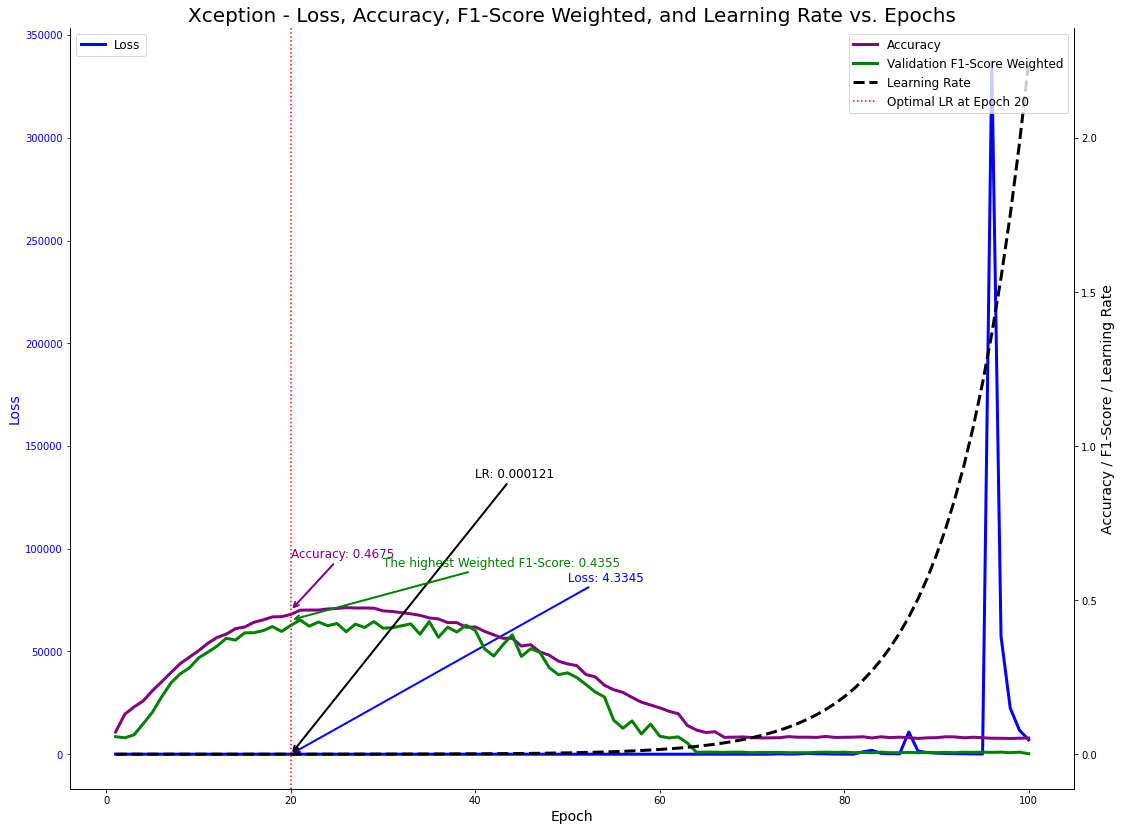

In [31]:
from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *

# 6. Display Learning Rate, Loss, Accuracy, and F1-Score Weighted all together across Epochs
display_lr_loss_accuracy_f1_across_epochs(history, model_name=model_name)

#####  Xception - Load  Training History for Verification - Optional

In [33]:
import pickle
import pandas as pd
import importlib

from src.modeling_image import lr_optimization
importlib.reload(lr_optimization)
importlib.reload(config)

# --- Configuration ---
model_name = 'Xception'
step_name = 'Step4'  # Adjust as needed
optimal_epoch = 20   # Epoch visually identified from the F1/Loss/Learning Rate plot
window = 2          # Epochs before and after for inspection

# --- Load history from .pkl file ---
history_filepath = MODEL_DIR / f'{step_name}_{model_name}_history.pkl'
with open(history_filepath, 'rb') as history_file:
    saved_history = pickle.load(history_file)

# --- Convert to DataFrame ---
history_df = pd.DataFrame(saved_history)

# --- Save as CSV for reference ---
csv_history_filepath = MODEL_DIR / f'{step_name}_{model_name}_history.csv'
history_df.to_csv(csv_history_filepath, index=False)

# --- Console Info ---
print("Loaded history keys:", saved_history.keys())
print(f"History shape: {history_df.shape}")
print(f"CSV saved to: {csv_history_filepath}")

# --- Optional Preview ---
print("First rows:")
display(history_df.head(2))

print("Last rows:")
display(history_df.tail(2))

# --- Epoch Verification Window ---
start = max(0, optimal_epoch - window)
end = min(len(history_df), optimal_epoch + window + 1)

print(f"Verifying values around optimal epoch**{optimal_epoch}** (window ±{window}):")
display(history_df.iloc[start:end])

# --- Wrap history in dummy object if needed for plotting functions ---
class History:
    def __init__(self, history_dict):
        self.history = history_dict

history = History(saved_history)



Loaded history keys: Index(['loss', 'accuracy', 'val_loss', 'val_accuracy', 'val_f1_score', 'lr'], dtype='object')
History shape: (100, 6)
CSV saved to: D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\models\image\lr_optimization\Step4_Xception_history.csv
First rows:


,loss,accuracy,val_loss,val_accuracy,val_f1_score,lr
0,16.817928,0.072133,14.377161,0.132803,0.056925,0.000010
1,15.821310,0.129987,13.859376,0.146643,0.053077,0.000011


Last rows:


,loss,accuracy,val_loss,val_accuracy,val_f1_score,lr
98,11644.807617,0.051892,8794.620117,0.059482,0.006679,1.982884
99,7000.763672,0.052554,5598.100098,0.029446,0.001685,2.245698


Verifying values around optimal epoch**20** (window ±2):


,loss,accuracy,val_loss,val_accuracy,val_f1_score,lr
18,5.093108,0.446415,4.369797,0.423439,0.398546,0.000094
19,4.694862,0.453776,3.960337,0.446702,0.418398,0.000106
20,4.334497,0.467467,3.609313,0.464370,0.435513,0.000121
21,4.038482,0.467982,3.426189,0.442580,0.415601,0.000137
22,3.790851,0.467982,3.160153,0.453769,0.429233,0.000155


 #### Step 3: Xception - Analyze the Results and Identify the Optimal Learning Rate

Based on the graph showing the **Loss**, **Accuracy**, **F1-Score Weighted**, and **Learning Rate** against **Epochs** for the **Xception** model, we can derive the following insights:

**Graph Analysis and Annotations**

- **Graph Annotations**:  
  At **Epoch 20**, the model reaches its best **Weighted F1-Score** of `0.4355` (green), with an **Accuracy** of `0.4675` (purple), a **Loss** of `4.3345` (blue), and a corresponding **Learning Rate** of `0.000121` (black dashed). This point is highlighted with a vertical red line.

- **Before the Peak**:  
  Prior to Epoch 20, all curves show a steady and consistent progression, indicating effective and stable learning.

- **After the Peak**:  
  Beyond this point, the **Loss** increases rapidly, and both **Accuracy** and **F1-Score** decline. This drop is linked to the steep rise in the **Learning Rate**, which destabilizes training.

- **Conclusion**:  
  The **optimal learning rate** for **Xception** is approximately **0.000121**, as identified at **Epoch 20**, where the model showed its best balance before performance degraded.


 ### 5.6 InceptionV3 - LR Range Test and Performance Analysis

#### Step 1: InceptionV3 - Build and Train with Learning Rate Range Test

In [34]:
%%time

model_name = 'InceptionV3' 

# Initialize the model using the build_model function.
model = build_model(
    model_name=model_name,
    input_shape=in_shape_299,
    num_classes=NUM_CLASSES,
    unfreeze_last_layers_count=None  
)

# Calling the train_model_and_save function 
model, history = train_model_and_save(
    model=model,
    train_data=train_gen_299x299,   # The subset of training data
    val_data=valid_gen_299x299,     # The subset of validation data
    epochs=EPOCHS,                 
    batch_size=BATCH_SIZE,         
    class_weight_dict=class_weight_dict,  # Apply class weights 
    learning_rate=LEARNING_RATE,        # Learning rate
    model_name=model_name,              # The model name for saving
    save_model_dir=MODEL_DIR,           # Directory to save the model and checkpoints
    step_name=STEP_NAME,                # The current step name (e.g., 'Step2', 'Step3') for proper file naming
    lr_scheduler=lr_scheduler           # Apply the Learning Rate Scheduler
)


[INFO] : Starting at epoch: 0, learning_rate: 9.999999747378752e-06
Epoch 1/100
213/213 [==============================] - ETA: 0s - loss: 16.9180 - accuracy: 0.0724
Epoch 1: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 96s 426ms/step - loss: 16.9180 - accuracy: 0.0724 - val_loss: 14.5519 - val_accuracy: 0.1422 - val_f1_score: 0.0476 - lr: 1.0000e-05
[INFO] : Learning rate updated from: 9.999999747378752e-06 to: 1.132541315152812e-05 at epoch 1
Epoch 2/100
213/213 [==============================] - ETA: 0s - loss: 15.9638 - accuracy: 0.1325
Epoch 2: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 92s 433ms/step - loss: 15.9638 - accuracy: 0.1325 - val_loss: 14.1337 - val_accuracy: 0.1605 - val_f1_score: 0.0582 - lr: 1.1325e-05
[INFO] : Learning rate updated from: 1.1325412742735352e-05 to: 1.2826498305280606e-05 at epoch 2
Epoch 3/100


[INFO] : Learning rate updated from: 6.468607898568735e-05 to: 7.325965428215231e-05 at epoch 16
Epoch 17/100
213/213 [==============================] - ETA: 0s - loss: 7.4558 - accuracy: 0.4370
Epoch 17: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 98s 462ms/step - loss: 7.4558 - accuracy: 0.4370 - val_loss: 6.6188 - val_accuracy: 0.4211 - val_f1_score: 0.3996 - lr: 7.3260e-05
[INFO] : Learning rate updated from: 7.325965270865709e-05 to: 8.29695852083491e-05 at epoch 17
Epoch 18/100
213/213 [==============================] - ETA: 0s - loss: 6.9098 - accuracy: 0.4541
Epoch 18: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 98s 459ms/step - loss: 6.9098 - accuracy: 0.4541 - val_loss: 6.1206 - val_accuracy: 0.4364 - val_f1_score: 0.4134 - lr: 8.2970e-05
[INFO] : Learning rate updated from: 8.296958549181e-05 to: 9.396648314954697e-05 a

[INFO] : Learning rate updated from: 0.00047388795064762235 to: 0.0005366976945540477 at epoch 32
Epoch 33/100
213/213 [==============================] - ETA: 0s - loss: 3.2174 - accuracy: 0.4480
Epoch 33: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 97s 456ms/step - loss: 3.2174 - accuracy: 0.4480 - val_loss: 2.5521 - val_accuracy: 0.4691 - val_f1_score: 0.4460 - lr: 5.3670e-04
[INFO] : Learning rate updated from: 0.0005366976838558912 to: 0.000607832312829723 at epoch 33
Epoch 34/100
213/213 [==============================] - ETA: 0s - loss: 3.2664 - accuracy: 0.4421
Epoch 34: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 97s 457ms/step - loss: 3.2664 - accuracy: 0.4421 - val_loss: 2.7588 - val_accuracy: 0.3996 - val_f1_score: 0.3756 - lr: 6.0783e-04
[INFO] : Learning rate updated from: 0.0006078323349356651 to: 0.00068839520696455

213/213 [==============================] - ETA: 0s - loss: 4.0981 - accuracy: 0.2274
Epoch 49: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 98s 459ms/step - loss: 4.0981 - accuracy: 0.2274 - val_loss: 3.0280 - val_accuracy: 0.2270 - val_f1_score: 0.1587 - lr: 0.0039
[INFO] : Learning rate updated from: 0.003931828774511814 to: 0.004452958509942656 at epoch 49
Epoch 50/100
213/213 [==============================] - ETA: 0s - loss: 4.1806 - accuracy: 0.2331
Epoch 50: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 98s 459ms/step - loss: 4.1806 - accuracy: 0.2331 - val_loss: 3.0652 - val_accuracy: 0.2291 - val_f1_score: 0.1569 - lr: 0.0045
[INFO] : Learning rate updated from: 0.004452958703041077 to: 0.005043159487171359 at epoch 50
Epoch 51/100
213/213 [==============================] - ETA: 0s - loss: 4.4820 - accuracy: 0.1958
Epoch 51:

213/213 [==============================] - ETA: 0s - loss: 465.9090 - accuracy: 0.0553
Epoch 81: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 98s 459ms/step - loss: 465.9090 - accuracy: 0.0553 - val_loss: 369.1837 - val_accuracy: 0.0559 - val_f1_score: 0.0059 - lr: 0.2110
[INFO] : Learning rate updated from: 0.2110203355550766 to: 0.2389892566231048 at epoch 81
Epoch 82/100
213/213 [==============================] - ETA: 0s - loss: 2274.0518 - accuracy: 0.0565
Epoch 82: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 97s 456ms/step - loss: 2274.0518 - accuracy: 0.0565 - val_loss: 758.4728 - val_accuracy: 0.0595 - val_f1_score: 0.0067 - lr: 0.2390
[INFO] : Learning rate updated from: 0.23898926377296448 to: 0.27066520700332414 at epoch 82
Epoch 83/100
213/213 [==============================] - ETA: 0s - loss: 2303.6665 - accuracy: 0.054

213/213 [==============================] - ETA: 0s - loss: 9231.6611 - accuracy: 0.0530
Epoch 97: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 98s 462ms/step - loss: 9231.6611 - accuracy: 0.0530 - val_loss: 6939.0918 - val_accuracy: 0.0559 - val_f1_score: 0.0059 - lr: 1.5459
[INFO] : Learning rate updated from: 1.5459277629852295 to: 1.7508270317357235 at epoch 97
Epoch 98/100
213/213 [==============================] - ETA: 0s - loss: 5601.1675 - accuracy: 0.0510
Epoch 98: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 97s 457ms/step - loss: 5601.1675 - accuracy: 0.0510 - val_loss: 4561.2935 - val_accuracy: 0.0294 - val_f1_score: 0.0017 - lr: 1.7508
[INFO] : Learning rate updated from: 1.7508270740509033 to: 1.9828839491270713 at epoch 98
Epoch 99/100
213/213 [==============================] - ETA: 0s - loss: 3850.7881 - accuracy: 0.0

#### Step 2: InceptionV3 - Visualizing the Learning Rate, Loss, Accuracy, and F1-Score for Model: InceptionV3 across Epochs

##### InceptionV3 - Display Learning Rate, Loss, Accuracy, and F1-Score Weighted across epochs

Y-axis range for Loss 3.1909570693969727 to 266602.1875
Y-axis range for Loss - loss_scale 133299.4982714653


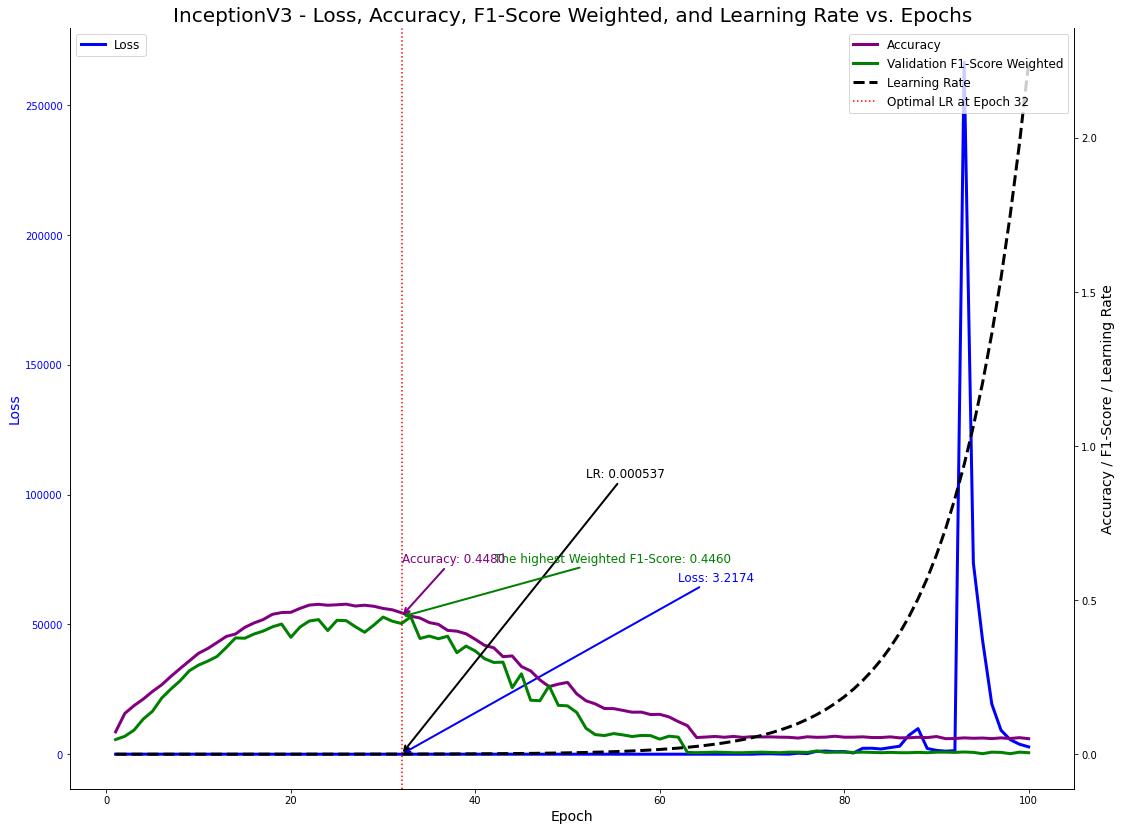

In [35]:
from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *

# 6. Display Learning Rate, Loss, Accuracy, and F1-Score Weighted all together across Epochs
display_lr_loss_accuracy_f1_across_epochs(history, model_name=model_name)

#####  InceptionV3 - Load Training History for Verification - Optional

In [36]:
import pickle
import pandas as pd
import importlib

from src.modeling_image import lr_optimization
importlib.reload(lr_optimization)
importlib.reload(config)

# --- Configuration ---
model_name = 'InceptionV3'
step_name = 'Step4'  # Adjust as needed
optimal_epoch = 32   # Epoch visually identified from the F1/Loss/Learning Rate plot
window = 2          # Epochs before and after for inspection

# --- Load history from .pkl file ---
history_filepath = MODEL_DIR / f'{step_name}_{model_name}_history.pkl'
with open(history_filepath, 'rb') as history_file:
    saved_history = pickle.load(history_file)

# --- Convert to DataFrame ---
history_df = pd.DataFrame(saved_history)

# --- Save as CSV for reference ---
csv_history_filepath = MODEL_DIR / f'{step_name}_{model_name}_history.csv'
history_df.to_csv(csv_history_filepath, index=False)

# --- Console Info ---
print("Loaded history keys:", saved_history.keys())
print(f"History shape: {history_df.shape}")
print(f"CSV saved to: {csv_history_filepath}")

# --- Optional Preview ---
print("First rows:")
display(history_df.head(2))

print("Last rows:")
display(history_df.tail(2))

# --- Epoch Verification Window ---
start = max(0, optimal_epoch - window)
end = min(len(history_df), optimal_epoch + window + 1)

print(f"Verifying values around optimal epoch**{optimal_epoch}** (window ±{window}):")
display(history_df.iloc[start:end])

# --- Wrap history in dummy object if needed for plotting functions ---
class History:
    def __init__(self, history_dict):
        self.history = history_dict

history = History(saved_history)



Loaded history keys: Index(['loss', 'accuracy', 'val_loss', 'val_accuracy', 'val_f1_score', 'lr'], dtype='object')
History shape: (100, 6)
CSV saved to: D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\models\image\lr_optimization\Step4_InceptionV3_history.csv
First rows:


,loss,accuracy,val_loss,val_accuracy,val_f1_score,lr
0,16.918005,0.072427,14.551929,0.142226,0.047569,0.000010
1,15.963810,0.132489,14.133717,0.160483,0.058156,0.000011


Last rows:


,loss,accuracy,val_loss,val_accuracy,val_f1_score,lr
98,3850.788086,0.053732,3263.921143,0.059482,0.006679,1.982884
99,2825.056641,0.050346,2434.735352,0.050648,0.004883,2.245698


Verifying values around optimal epoch**32** (window ±2):


,loss,accuracy,val_loss,val_accuracy,val_f1_score,lr
30,3.190957,0.468718,2.606891,0.462309,0.431708,0.000418
31,3.198757,0.459149,2.644393,0.439635,0.424175,0.000474
32,3.217355,0.447961,2.552145,0.469081,0.445970,0.000537
33,3.266399,0.442146,2.758785,0.399588,0.375554,0.000608
34,3.344958,0.427425,2.722676,0.415194,0.383496,0.000688


#### Step 3:  InceptionV3 - Analyze the Results and Identify the Optimal Learning Rate

Based on the graph showing the **Loss**, **Accuracy**, **F1-Score Weighted**, and **Learning Rate** against **Epochs** for the **InceptionV3** model, we can derive the following insights:

**Graph Analysis and Annotations**

- **Graph Annotations**:  
  At **Epoch 32**, the model achieves its best **Weighted F1-Score** of `0.4460`, with an **Accuracy** of `0.4480`, a **Loss** of `3.2174`, and a **Learning Rate** of `0.000537`. This is highlighted by the vertical red line on the plot.

- **Before the Peak**:  
  The metrics improve consistently, indicating stable and effective training.

- **After the Peak**:  
  After Epoch 32, the **Loss** increases sharply and both **Accuracy** and **F1-Score** start to degrade, reflecting model instability likely due to a too high learning rate.

- **Conclusion**:  
  The **optimal learning rate** for **InceptionV3** is approximately **0.000537**, corresponding to **Epoch 32**, where the model shows its best performance before instability occurs.


---

# 6. Results and Next Steps

## Learning Rate Optimization Results

In this step, we have optimized the learning rate for each of the top-performing models, including **MobileNetV2**, **DenseNet121**, **InceptionResNetV2**, **Xception**, and **InceptionV3**. After analyzing the **F1-Score Weighted** and the corresponding loss, we identified the best learning rates for each model. Below are the results:

- **DenseNet121**: Best Learning Rate = **[0.000225]**
- **MobileNetV2**: Best Learning Rate = **[insert best LR here]**
- **InceptionResNetV2**: Best Learning Rate = **[insert best LR here]**
- **Xception**: Best Learning Rate = **[0.000106]**
- **InceptionV3**: Best Learning Rate = **[0.000225]**

### Next Step: Notebook 21 - Final Tuning

In the next notebook, `21_Image_Final_Tuning.ipynb`, we will proceed with the following steps:

1. **Training**: We will train all 5 models using the optimized learning rates obtained during the learning rate optimization step.
2. **Data Augmentation**: Data augmentation will be applied to further improve model generalization.
3. **Fine-Tuning**: We will unfreeze some of the last layers of the pre-trained models and fine-tune them using the optimized learning rates.
4. **Evaluation**: Finally, we will evaluate the models using the **F1-Score Weighted** to determine their performance on the validation set and identify the best-performing model.

By the end of this process, we aim to have the most optimized models ready for final deployment and further improvements.
